Configuración cargada: https://data-charts-api.hexlet.app 2023-03-01 2023-09-01
Descargando visits_1k.csv...
  OK: visits_1k.csv guardado correctamente
Descargando regs_1k.csv...
  OK: regs_1k.csv guardado correctamente
Descargando ads.csv...
  OK: ads.csv guardado correctamente

Descarga finalizada.
INICIO DEL PROCESAMIENTO
TOTAL_VISITS = 263459

Datos cargados correctamente.
Registros: 21836
Visitas: 256077
Publicidad: 159

REGISTROS


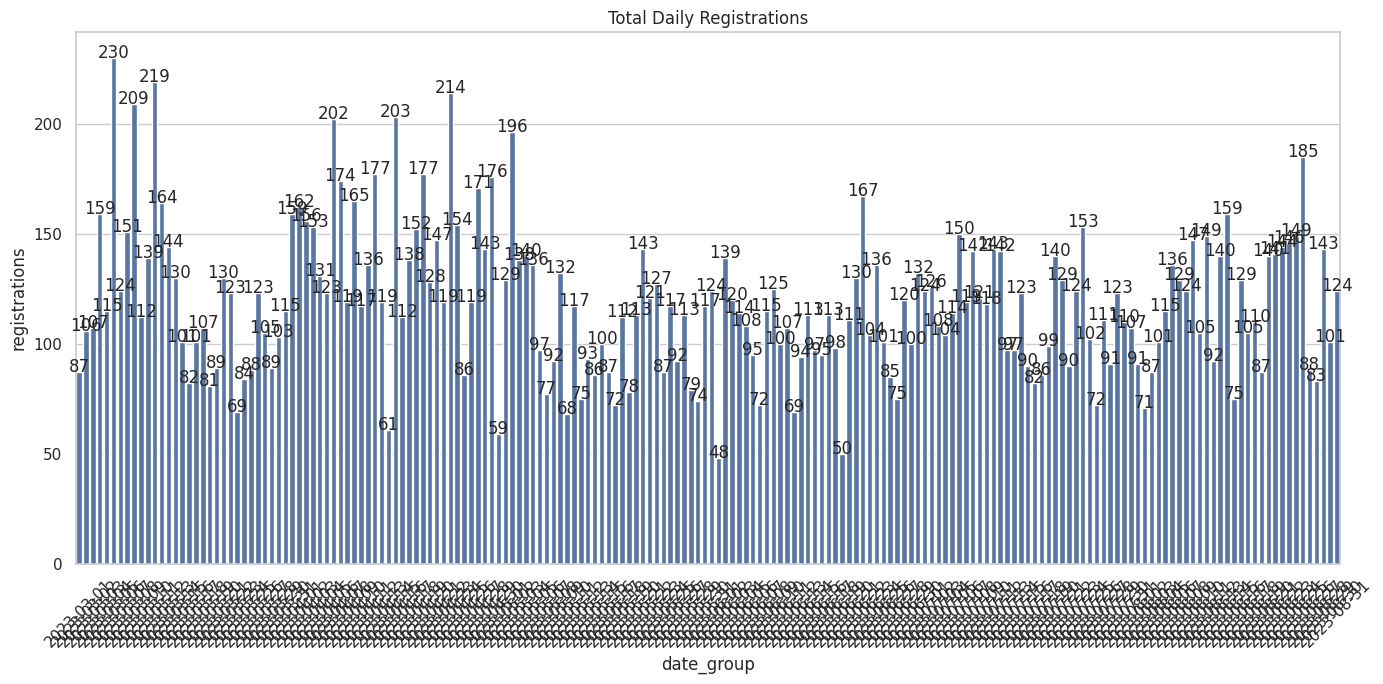

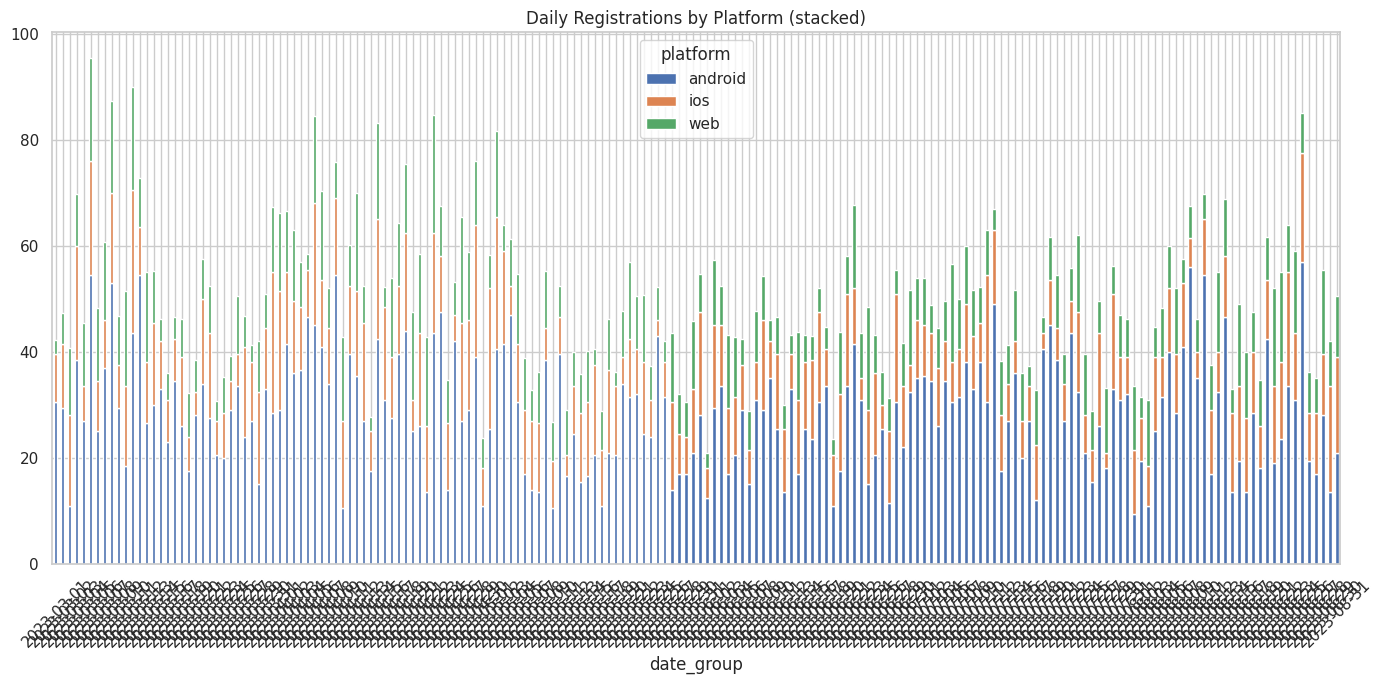

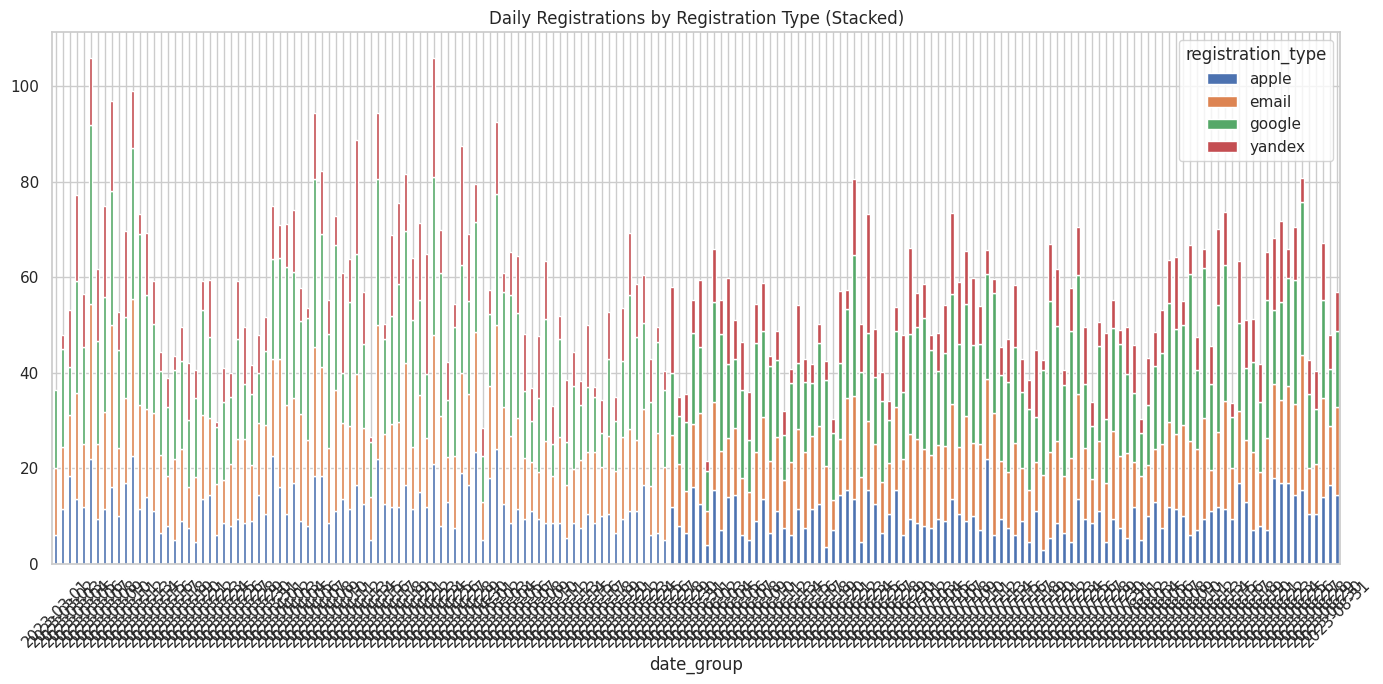

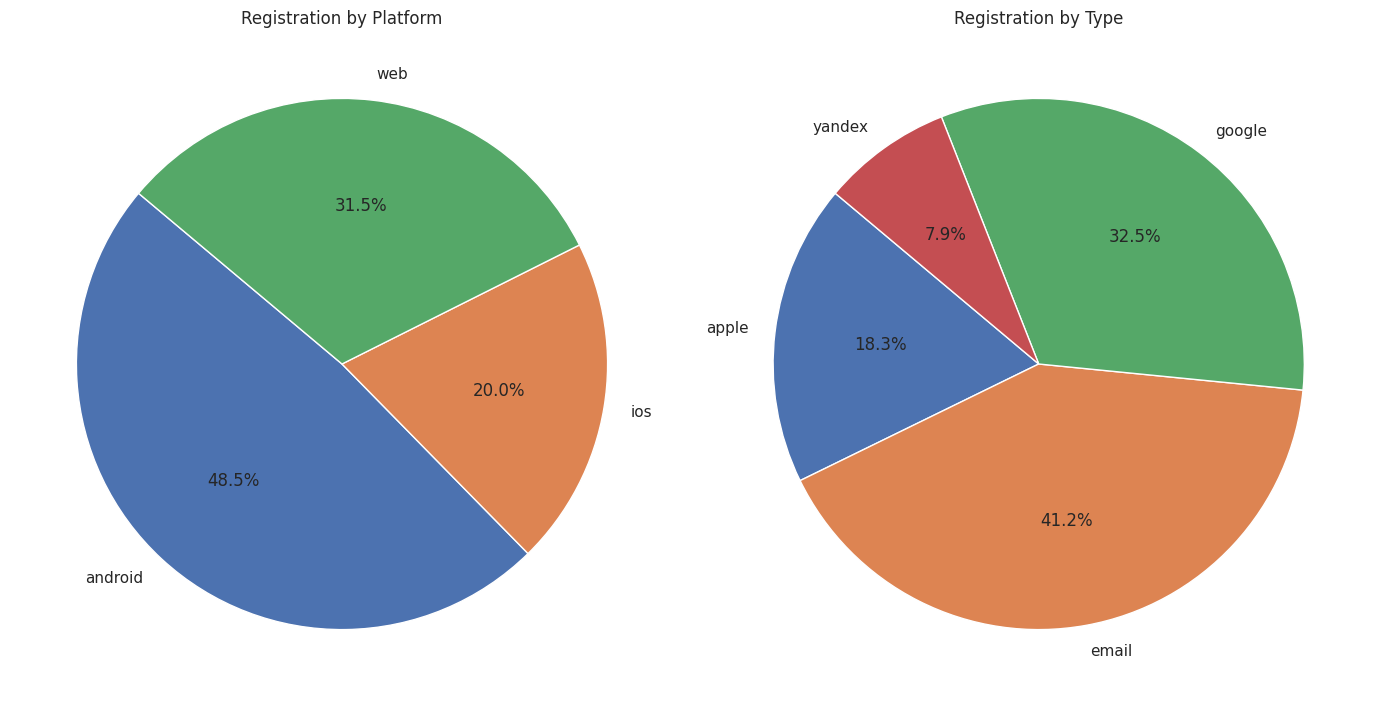


VISITAS


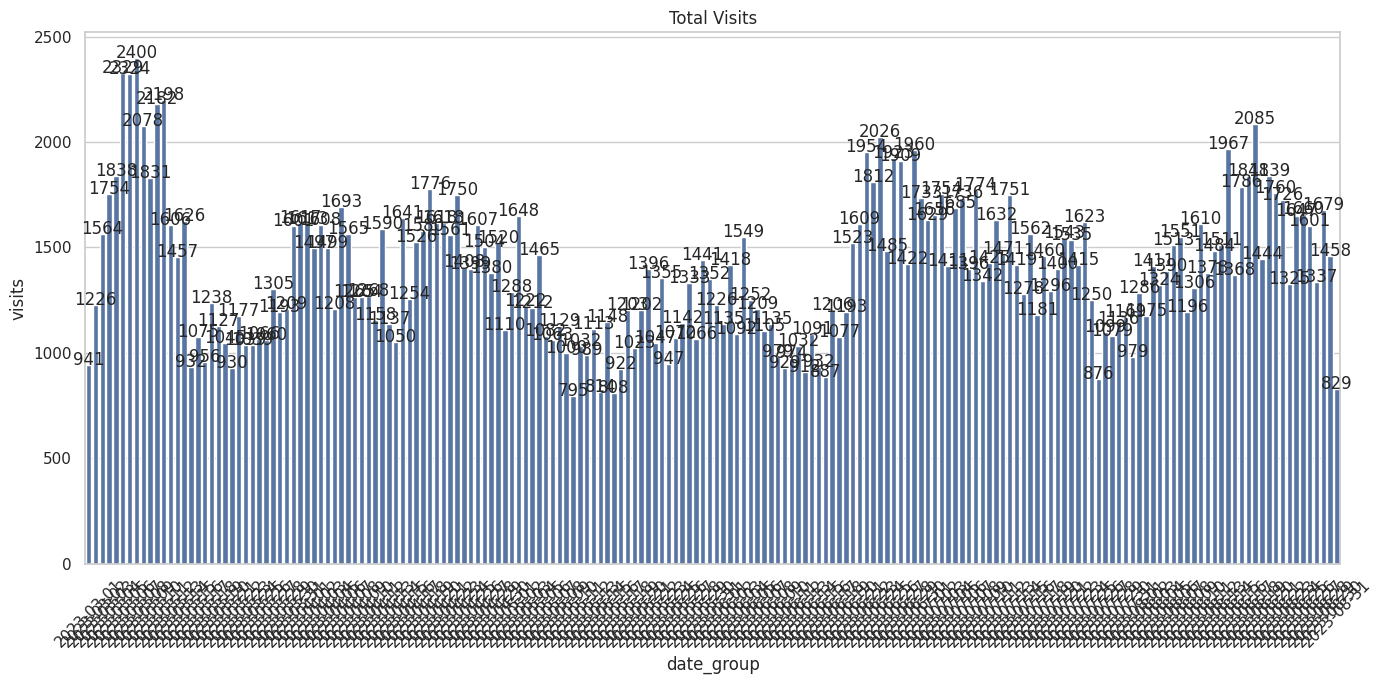

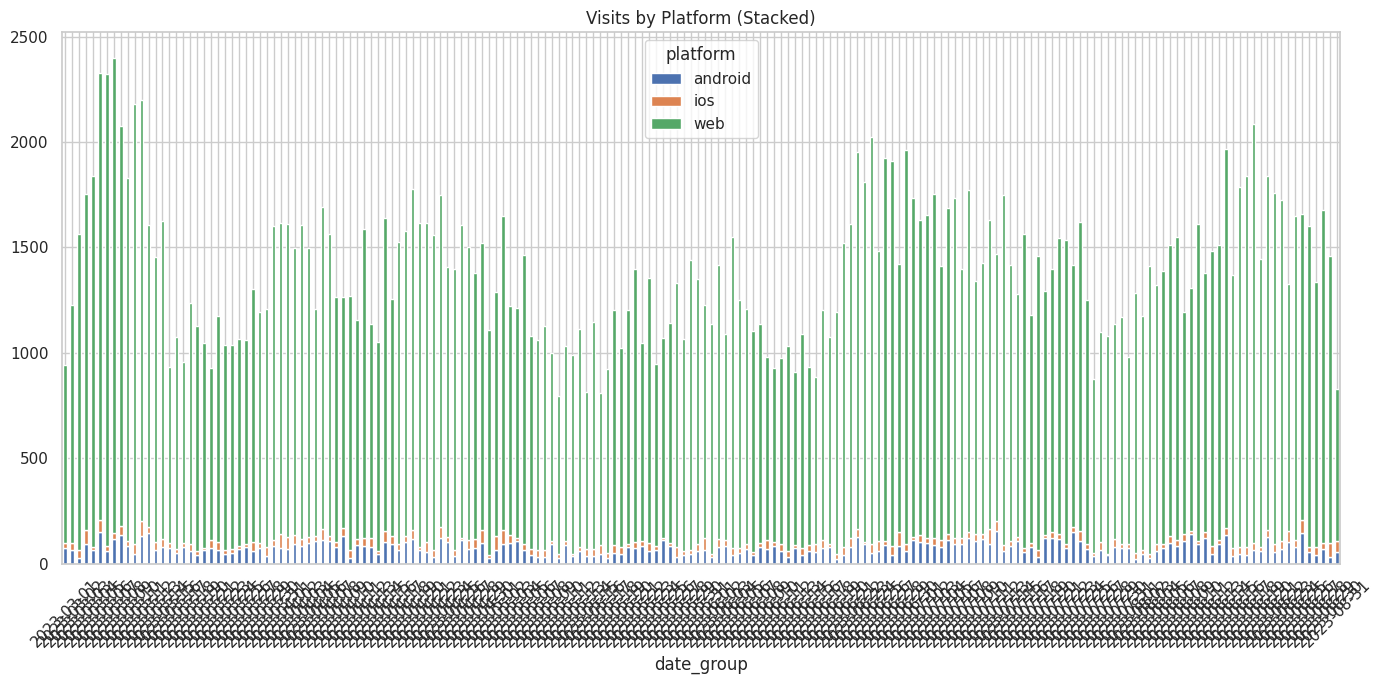


CONVERSIÓN

Conversion:


,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,844,8,0.947867
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355



conversion.json generado correctamente.


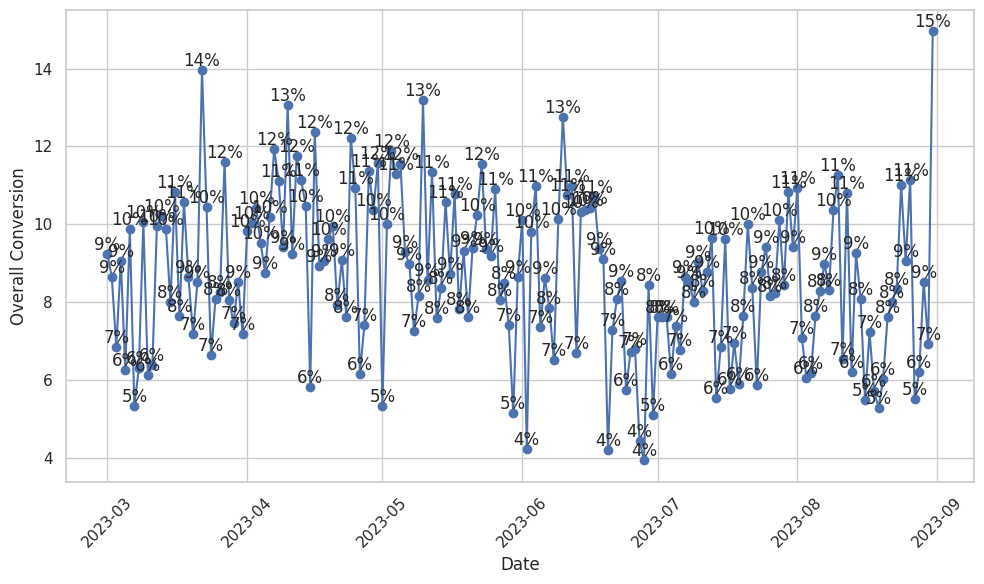

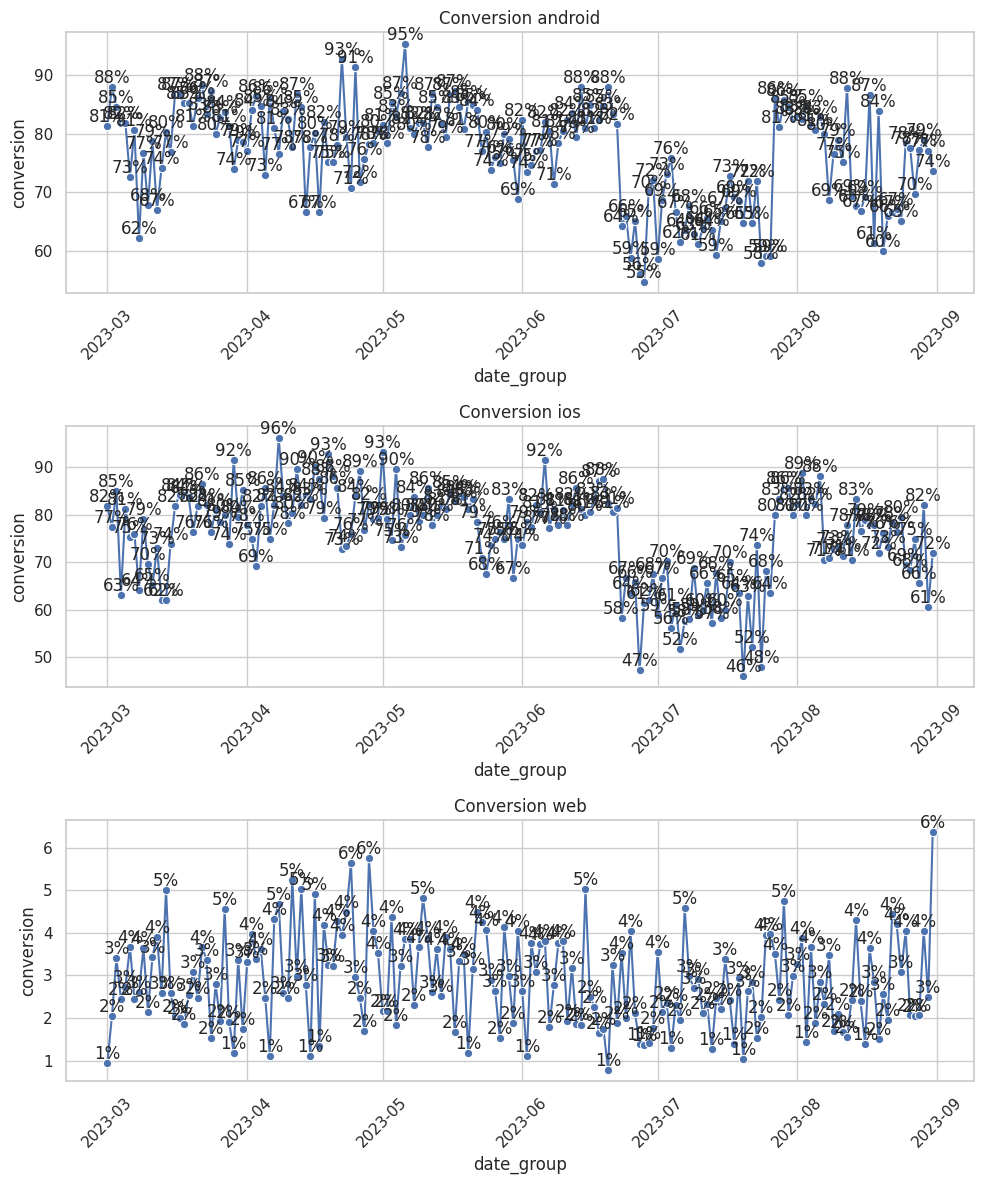


PUBLICIDAD / FASE 4

Ads:


,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,941,87,212.0,advanced_algorithms_series
1,2023-03-02,1226,106,252.0,advanced_algorithms_series
2,2023-03-03,1564,107,202.0,advanced_algorithms_series
3,2023-03-04,1754,159,223.0,advanced_algorithms_series
4,2023-03-05,1838,115,265.0,advanced_algorithms_series



ads.json generado correctamente.

COSTOS DE PUBLICIDAD


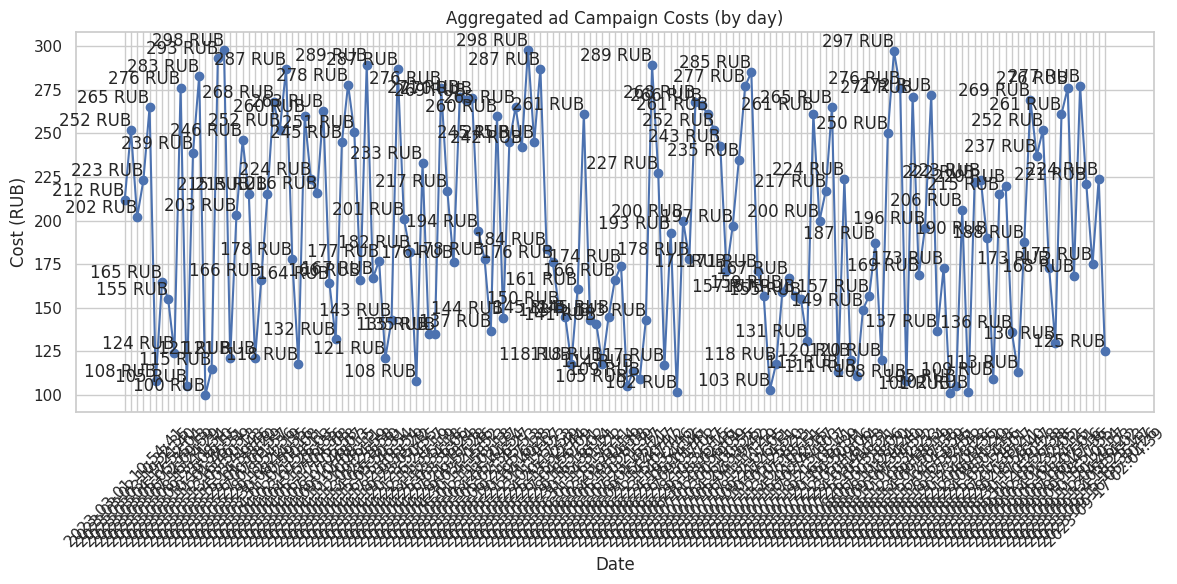


PROCESO FINALIZADO

Archivos JSON:
  OK conversion.json
  OK ads.json

Gráficos generados:
  OK charts/ads_costs.png
  OK charts/conversion.png
  OK charts/conversion_by_platforms.png
  OK charts/total_registrations.png
  OK charts/total_registrations_by_platform.png
  OK charts/total_registrations_by_type.png
  OK charts/total_registrations_by_type_pie.png
  OK charts/total_visits.png
  OK charts/total_visits_by_platform.png

Proceso completado.


In [2]:
# ==============================================================
# FUNDAMENTOS / ANÁLISIS DE DATOS
# Código completo para Google Colab
# ==============================================================

# ==============================================================
# 0. INSTALACIÓN DE LIBRERÍAS
# ==============================================================

!pip install -q python-dotenv
!pip install -q plotly python-dotenv


# ==============================================================
# 1. IMPORTACIONES
# ==============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import requests

from dotenv import load_dotenv


# ==============================================================
# 2. CONFIGURACIÓN GENERAL
# ==============================================================

load_dotenv(".env", override=True)

API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")

if not all([API_URL, DATE_BEGIN, DATE_END]):
    raise ValueError(
        f"Faltan variables en .env -> API_URL={API_URL}, "
        f"DATE_BEGIN={DATE_BEGIN}, DATE_END={DATE_END}"
    )

print("Configuración cargada:", API_URL, DATE_BEGIN, DATE_END)

# Carpetas de trabajo
Path("data").mkdir(exist_ok=True)
Path("charts").mkdir(exist_ok=True)

sns.set(style="whitegrid")


# ==============================================================
# 3. DESCARGA DE CSV DESDE GOOGLE DRIVE
# ==============================================================

archivos_a_descargar = {
    "1QosQQ4RRNR9rkL4t7sB707h2Uy0XfYJe": "visits_1k.csv",
    "1AeQz0kaSgz0lxYSDtuNm36muhy5fRCzZ": "regs_1k.csv",
    "12vCtGhJlcK_CBcs8ES3BfEPbk6OJ45Qj": "ads.csv",
}


for file_id, file_name in archivos_a_descargar.items():

    print(f"Descargando {file_name}...")

    url = (
        "https://drive.google.com/uc"
        f"?export=download&id={file_id}"
    )

    try:
        response = requests.get(
            url,
            timeout=30
        )

        response.raise_for_status()

        with open(file_name, "wb") as f:
            f.write(response.content)

        print(f"  OK: {file_name} guardado correctamente")

    except requests.exceptions.RequestException as e:
        print(
            f"  ERROR descargando {file_name}: {e}"
        )


print("\nDescarga finalizada.")


# ==============================================================
# 4. FUNCIONES DE LIMPIEZA
# ==============================================================

def clean_registration_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia los datos de registros.
    """

    df = df.drop_duplicates().copy()

    # Si no existe platform, la creamos como web.
    if "platform" not in df.columns:
        df["platform"] = "web"

    df["platform"] = (
        df["platform"]
        .fillna("web")
        .astype(str)
        .str.strip()
    )

    return df


def clean_visit_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    print("TOTAL_VISITS =", len(df))

    df["visit_dt"] = pd.to_datetime(df["visit_dt"], errors="coerce")
    df = df.dropna(subset=["visit_dt"])

    # Excluir bots
    df = df[
        ~df["user_agent"].astype(str).str.contains("bot", case=False, na=False)
    ]

    if "platform" in df.columns:
        df["platform"] = df["platform"].astype(str).str.strip("*").str.strip()
    else:
        df["platform"] = "web"

    return df


def clean_ads_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia los datos de publicidad.
    """

    df = df.drop_duplicates().copy()

    if "date" in df.columns:
        df["date"] = pd.to_datetime(
            df["date"],
            errors="coerce"
        )

    if "cost" in df.columns:
        df["cost"] = pd.to_numeric(
            df["cost"],
            errors="coerce"
        ).fillna(0)

    return df


# ==============================================================
# 5. FUNCIONES AUXILIARES DE FECHAS
# ==============================================================

def _assign_date_group(
    df,
    col_dt,
    date_group
):
    """
    Agrupa una fecha por día, semana, mes o trimestre.
    """

    if date_group == "day":
        return (
            df[col_dt]
            .dt.to_period("D")
            .dt.start_time
            .dt.date
        )

    if date_group == "week":
        return (
            df[col_dt]
            .dt.to_period("W")
            .dt.start_time
            .dt.date
        )

    if date_group == "month":
        return (
            df[col_dt]
            .dt.to_period("M")
            .dt.start_time
            .dt.date
        )

    if date_group == "quarter":
        return (
            df[col_dt]
            .dt.to_period("Q")
            .dt.start_time
            .dt.date
        )

    raise ValueError(
        f"date_group inválido: {date_group}"
    )


# ==============================================================
# 6. AGREGACIÓN DE REGISTROS
# ==============================================================

def filter_and_aggregate_registration_data(
    df,
    date_start,
    date_end,
    date_group
):
    """
    Filtra los registros por rango de fechas y
    genera dos DataFrames:

    1. Agrupado por fecha + plataforma + tipo.
    2. Agrupado por fecha + plataforma.
    """

    date_start = pd.to_datetime(
        date_start
    )

    date_end = pd.to_datetime(
        date_end
    )

    if "registration_dt" not in df.columns:
        raise ValueError(
            "'registration_dt' no existe en el DataFrame"
        )

    df = df.copy()

    df["registration_dt"] = pd.to_datetime(
        df["registration_dt"],
        errors="coerce"
    )

    # Eliminar fechas inválidas
    df = df.dropna(
        subset=["registration_dt"]
    )

    mask = (
        (df["registration_dt"] >= date_start)
        &
        (df["registration_dt"] <= date_end)
    )

    filtered = df.loc[mask].copy()

    if filtered.empty:
        print(
            "No hay registros en el rango dado."
        )

        return (
            pd.DataFrame(),
            pd.DataFrame()
        )

    filtered["date_group"] = _assign_date_group(
        filtered,
        "registration_dt",
        date_group
    )

    # Asegurar platform
    if "platform" not in filtered.columns:
        filtered["platform"] = "web"

    filtered["platform"] = (
        filtered["platform"]
        .fillna("web")
        .astype(str)
        .str.strip()
    )

    # Si registration_type no existe,
    # crear una categoría genérica.
    if "registration_type" not in filtered.columns:
        filtered["registration_type"] = "unknown"

    filtered["registration_type"] = (
        filtered["registration_type"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )

    # Con tipo de registro
    with_type = (
        filtered
        .groupby(
            [
                "date_group",
                "platform",
                "registration_type"
            ]
        )
        .size()
        .reset_index(
            name="registrations"
        )
        .sort_values(
            "date_group"
        )
    )

    # Sin tipo de registro
    without_type = (
        filtered
        .groupby(
            [
                "date_group",
                "platform"
            ]
        )
        .size()
        .reset_index(
            name="registrations"
        )
        .sort_values(
            "date_group"
        )
    )

    return (
        with_type,
        without_type
    )


# ==============================================================
# 7. AGREGACIÓN DE VISITAS
# ==============================================================

def filter_and_aggregate_visit_data(
    df,
    date_start,
    date_end,
    date_group
):
    """
    Filtra y agrupa las visitas.
    """

    date_start = pd.to_datetime(
        date_start
    )

    date_end = pd.to_datetime(
        date_end
    )

    df = df.copy()

    df["visit_dt"] = pd.to_datetime(
        df["visit_dt"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["visit_dt"]
    )

    mask = (
        (df["visit_dt"] >= date_start)
        &
        (df["visit_dt"] <= date_end)
    )

    filtered = df.loc[mask].copy()

    if filtered.empty:
        print(
            "No hay visitas en el rango dado."
        )

        return pd.DataFrame()

    filtered["date_group"] = _assign_date_group(
        filtered,
        "visit_dt",
        date_group
    )

    if "platform" not in filtered.columns:
        filtered["platform"] = "web"

    filtered["platform"] = (
        filtered["platform"]
        .fillna("web")
        .astype(str)
        .str.strip()
    )

    return (
        filtered
        .groupby(
            [
                "date_group",
                "platform"
            ]
        )
        .size()
        .reset_index(
            name="visits"
        )
        .sort_values(
            "date_group"
        )
    )


# ==============================================================
# 8. CREAR DATAFRAME DE PUBLICIDAD + CONVERSIONES
# ==============================================================

def create_ads_dataframe(
    conversion_df,
    ads_df,
    date_start,
    date_end
):
    """
    Combina los datos de conversiones con
    las campañas publicitarias agrupando por fecha.
    """

    date_start = pd.to_datetime(
        date_start
    ).normalize()

    date_end = pd.to_datetime(
        date_end
    ).normalize()

    # ----------------------------------------------------------
    # 1. Conversiones
    # ----------------------------------------------------------

    conversion = conversion_df.copy()

    conversion["date_group"] = pd.to_datetime(
        conversion["date_group"]
    ).dt.normalize()

    conversion_daily = (
        conversion
        .groupby(
            "date_group",
            as_index=False
        )
        .agg(
            visits=("visits", "sum"),
            registrations=("registrations", "sum")
        )
    )

    # ----------------------------------------------------------
    # 2. Campañas publicitarias
    # ----------------------------------------------------------

    ads = ads_df.copy()

    ads["date"] = pd.to_datetime(
        ads["date"],
        errors="coerce"
    )

    ads = ads.dropna(
        subset=["date"]
    )

    ads["date_group"] = (
        ads["date"]
        .dt.normalize()
    )

    # Filtrar período
    ads = ads[
        (ads["date_group"] >= date_start)
        &
        (ads["date_group"] <= date_end)
    ].copy()

    # ----------------------------------------------------------
    # 3. Agrupar campañas por día
    # ----------------------------------------------------------

    if ads.empty:

        ads_daily = pd.DataFrame(
            columns=[
                "date_group",
                "cost",
                "utm_campaign"
            ]
        )

    else:

        # Si no existe utm_campaign
        if "utm_campaign" not in ads.columns:
            ads["utm_campaign"] = "none"

        ads_daily = (
            ads
            .groupby(
                "date_group",
                as_index=False
            )
            .agg(
                cost=("cost", "sum"),
                utm_campaign=(
                    "utm_campaign",
                    "first"
                )
            )
        )

    # ----------------------------------------------------------
    # 4. Combinar conversiones + publicidad
    # ----------------------------------------------------------

    result = pd.merge(
        conversion_daily,
        ads_daily,
        on="date_group",
        how="left"
    )

    # ----------------------------------------------------------
    # 5. Días sin publicidad
    # ----------------------------------------------------------

    result["cost"] = (
        result["cost"]
        .fillna(0)
    )

    result["utm_campaign"] = (
        result["utm_campaign"]
        .fillna("none")
    )

    # ----------------------------------------------------------
    # 6. Orden cronológico
    # ----------------------------------------------------------

    result = (
        result
        .sort_values(
            "date_group"
        )
        .reset_index(
            drop=True
        )
    )

    # ----------------------------------------------------------
    # 7. Guardar JSON
    # ----------------------------------------------------------

    result.to_json(
        "./ads.json",
        orient="records",
        date_format="iso"
    )

    return result


# ==============================================================
# 9. CARGA DE DATOS DESDE LA API
# ==============================================================

def load_data(
    date_start=DATE_BEGIN,
    date_end=DATE_END
):

    # ----------------------------------------------------------
    # REGISTROS
    # ----------------------------------------------------------

    response = requests.get(
        f"{API_URL}/registrations",
        params={
            "begin": date_start,
            "end": date_end
        },
        timeout=30
    )

    response.raise_for_status()

    regs = pd.DataFrame(
        response.json()
    )

    regs = regs.rename(
        columns={
            "datetime": "registration_dt"
        }
    )

    # ----------------------------------------------------------
    # VISITAS
    # ----------------------------------------------------------

    response = requests.get(
        f"{API_URL}/visits",
        params={
            "begin": date_start,
            "end": date_end
        },
        timeout=30
    )

    response.raise_for_status()

    visits = pd.DataFrame(
        response.json()
    )

    visits = visits.rename(
        columns={
            "visit_id": "anonymous_id",
            "datetime": "visit_dt"
        }
    )

    # ----------------------------------------------------------
    # CAMPAÑAS PUBLICITARIAS
    # ----------------------------------------------------------

    ads = pd.read_csv(
        "./ads.csv"
    )

    # ----------------------------------------------------------
    # LIMPIEZA
    # ----------------------------------------------------------

    clean_regs = clean_registration_data(
        regs
    )

    clean_visits = clean_visit_data(
        visits
    )

    ads_cleaned = clean_ads_data(
        ads
    )

    return (
        clean_regs,
        clean_visits,
        ads_cleaned
    )


# ==============================================================
# 10. MERGE + CÁLCULO DE CONVERSIÓN
# ==============================================================

def merge_dataframes_and_calculate_conversion(
    df_visits,
    df_registrations
):
    merged = pd.merge(
        df_visits,
        df_registrations,
        on=["date_group", "platform"],
        how="outer"
    )

    # Valores faltantes
    merged["visits"] = (
        pd.to_numeric(
            merged["visits"],
            errors="coerce"
        )
        .fillna(0)
    )

    merged["registrations"] = (
        pd.to_numeric(
            merged["registrations"],
            errors="coerce"
        )
        .fillna(0)
    )

    # Cálculo de conversión
    merged["conversion"] = np.where(
        merged["visits"] > 0,
        merged["registrations"] / merged["visits"] * 100,
        0
    )

    # Orden cronológico
    merged = (
        merged
        .sort_values(
            ["date_group", "platform"]
        )
        .reset_index(drop=True)
    )

    # Guardar todo el DataFrame en JSON
    merged.to_json(
        "./conversion.json"
    )

    return merged


# ==============================================================
# 11. PERÍODOS CONTINUOS DE CAMPAÑA
# ==============================================================

def get_continuous_campaign_periods(
    df,
    date_group
):
    """
    Obtiene los períodos continuos de cada campaña.
    """

    day_map = {
        "day": 1,
        "week": 7,
        "month": 30,
        "quarter": 90
    }

    if date_group not in day_map:
        raise ValueError(
            f"date_group inválido: {date_group}"
        )

    if df.empty:
        return pd.DataFrame()

    if "full_ad" not in df.columns:
        return pd.DataFrame()

    periods = []

    for campaign in df["full_ad"].dropna().unique():

        cdata = (
            df[
                df["full_ad"] == campaign
            ]
            .copy()
            .sort_values(
                "date_group"
            )
        )

        if cdata.empty:
            continue

        cdata["date_group"] = pd.to_datetime(
            cdata["date_group"]
        )

        cdata["gap"] = (
            cdata["date_group"]
            .diff()
            .dt.days
            > day_map[date_group]
        )

        cdata["period"] = (
            cdata["gap"]
            .fillna(False)
            .cumsum()
        )

        cp = (
            cdata
            .groupby("period")
            .agg(
                start=(
                    "date_group",
                    "min"
                ),
                end=(
                    "date_group",
                    "max"
                )
            )
            .reset_index(drop=True)
        )

        cp["campaign"] = campaign

        periods.append(cp)

    if not periods:
        return pd.DataFrame()

    return pd.concat(
        periods,
        ignore_index=True
    )


# ==============================================================
# 12. VISUALIZACIONES DE REGISTROS
# ==============================================================

def visualize_aggregated_registration_data(
    aggregated_data
):

    # ----------------------------------------------------------
    # 12.1 Total por día
    # ----------------------------------------------------------

    plt.figure(
        figsize=(14, 7)
    )

    total = (
        aggregated_data
        .groupby(
            "date_group"
        )["registrations"]
        .sum()
        .reset_index()
    )

    sns.barplot(
        data=total,
        x="date_group",
        y="registrations"
    )

    plt.title(
        "Total Daily Registrations"
    )

    for i, row in total.iterrows():

        plt.text(
            i,
            row["registrations"],
            round(
                row["registrations"],
                2
            ),
            ha="center"
        )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/total_registrations.png"
    )

    plt.show()

    # ----------------------------------------------------------
    # 12.2 Por plataforma
    # ----------------------------------------------------------

    pivot = (
        aggregated_data
        .pivot_table(
            index="date_group",
            columns="platform",
            values="registrations",
            fill_value=0
        )
    )

    pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 7)
    )

    plt.title(
        "Daily Registrations by Platform (stacked)"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/total_registrations_by_platform.png"
    )

    plt.show()

    # ----------------------------------------------------------
    # 12.3 Por tipo de registro
    # ----------------------------------------------------------

    pivot = (
        aggregated_data
        .pivot_table(
            index="date_group",
            columns="registration_type",
            values="registrations",
            fill_value=0
        )
    )

    pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 7)
    )

    plt.title(
        "Daily Registrations by Registration Type (Stacked)"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/total_registrations_by_type.png"
    )

    plt.show()

    # ----------------------------------------------------------
    # 12.4 Pie charts
    # ----------------------------------------------------------

    platform_pie = (
        aggregated_data
        .groupby("platform")["registrations"]
        .sum()
    )

    type_pie = (
        aggregated_data
        .groupby("registration_type")["registrations"]
        .sum()
    )

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(14, 7)
    )

    ax[0].pie(
        platform_pie,
        labels=platform_pie.index,
        autopct="%1.1f%%",
        startangle=140
    )

    ax[0].set_title(
        "Registration by Platform"
    )

    ax[1].pie(
        type_pie,
        labels=type_pie.index,
        autopct="%1.1f%%",
        startangle=140
    )

    ax[1].set_title(
        "Registration by Type"
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/total_registrations_by_type_pie.png"
    )

    plt.show()


# ==============================================================
# 13. VISUALIZACIONES DE VISITAS
# ==============================================================

def visualize_aggregated_visits_data(
    aggregated_data
):

    # ----------------------------------------------------------
    # Total de visitas
    # ----------------------------------------------------------

    plt.figure(
        figsize=(14, 7)
    )

    total = (
        aggregated_data
        .groupby(
            "date_group"
        )["visits"]
        .sum()
        .reset_index()
    )

    sns.barplot(
        data=total,
        x="date_group",
        y="visits"
    )

    plt.title(
        "Total Visits"
    )

    plt.xticks(
        rotation=45
    )

    for i, row in total.iterrows():

        plt.text(
            i,
            row["visits"],
            round(
                row["visits"],
                2
            ),
            ha="center"
        )

    plt.tight_layout()

    plt.savefig(
        "./charts/total_visits.png"
    )

    plt.show()

    # ----------------------------------------------------------
    # Visitas por plataforma
    # ----------------------------------------------------------

    pivot = (
        aggregated_data
        .pivot_table(
            index="date_group",
            columns="platform",
            values="visits",
            fill_value=0
        )
    )

    pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 7)
    )

    plt.title(
        "Visits by Platform (Stacked)"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/total_visits_by_platform.png"
    )

    plt.show()


# ==============================================================
# 14. GRÁFICOS DE CONVERSIÓN
# ==============================================================

def plot_conversion_graphs(df):

    # ----------------------------------------------------------
    # Conversión global
    # ----------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )

    overall = (
        df
        .groupby(
            "date_group"
        )
        .agg(
            visits=("visits", "sum"),
            registrations=(
                "registrations",
                "sum"
            )
        )
    )

    overall["conversion"] = np.where(
        overall["visits"] > 0,
        (
            overall["registrations"]
            /
            overall["visits"]
            *
            100
        ),
        0
    )

    plt.plot(
        overall.index,
        overall["conversion"],
        marker="o"
    )

    for i in range(
        len(overall)
    ):

        plt.text(
            overall.index[i],
            overall["conversion"].iloc[i],
            f"{overall['conversion'].iloc[i]:.0f}%",
            ha="center",
            va="bottom"
        )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Overall Conversion"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/conversion.png"
    )

    plt.show()

    # ----------------------------------------------------------
    # Conversión por plataforma
    # ----------------------------------------------------------

    platforms = (
        df["platform"]
        .dropna()
        .unique()
    )

    if len(platforms) == 0:
        return

    fig, axes = plt.subplots(
        len(platforms),
        1,
        figsize=(
            10,
            4 * len(platforms)
        ),
        squeeze=False
    )

    axes = axes.flatten()

    for i, platform in enumerate(
        platforms
    ):

        pdata = (
            df[
                df["platform"] == platform
            ]
            .copy()
            .sort_values(
                "date_group"
            )
        )

        sns.lineplot(
            x="date_group",
            y="conversion",
            data=pdata,
            marker="o",
            ax=axes[i]
        )

        for x, y in pdata[
            [
                "date_group",
                "conversion"
            ]
        ].values:

            axes[i].text(
                x,
                y,
                f"{y:.0f}%",
                ha="center",
                va="bottom"
            )

        axes[i].set_title(
            f"Conversion {platform}"
        )

        axes[i].tick_params(
            axis="x",
            rotation=45
        )

    plt.tight_layout()

    plt.savefig(
        "./charts/conversion_by_platforms.png"
    )

    plt.show()


# ==============================================================
# 15. COSTOS DE PUBLICIDAD
# ==============================================================

def visualize_aggregated_ads_data(
    df,
    date_group
):

    plt.figure(
        figsize=(12, 6)
    )

    x = (
        df["date_group"]
        .astype(str)
    )

    y = df["cost"]

    plt.plot(
        x,
        y,
        marker="o"
    )

    for i, label in enumerate(y):

        plt.text(
            x.iloc[i],
            y.iloc[i],
            f"{label} RUB",
            ha="right",
            va="bottom"
        )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Cost (RUB)"
    )

    plt.title(
        f"Aggregated ad Campaign Costs (by {date_group})"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/ads_costs.png"
    )

    plt.show()


# ==============================================================
# 16. VISUALIZACIÓN COMBINADA
# ==============================================================

def visualize_combined_data(
    agg_visits,
    agg_regs,
    df_ads_periods
):

    if df_ads_periods.empty:
        return

    plt.figure(
        figsize=(12, 12)
    )

    campaigns = (
        df_ads_periods["campaign"]
        .dropna()
        .unique()
    )

    colors = dict(
        zip(
            campaigns,
            mcolors.TABLEAU_COLORS
        )
    )

    # ----------------------------------------------------------
    # VISITAS
    # ----------------------------------------------------------

    plt.subplot(
        2,
        1,
        1
    )

    tv = (
        agg_visits
        .groupby(
            "date_group"
        )["visits"]
        .sum()
        .reset_index()
    )

    plt.plot(
        tv["date_group"],
        tv["visits"],
        color="black",
        label="Visits",
        marker="o"
    )

    plt.axhline(
        y=tv["visits"].mean(),
        color="gray",
        linestyle="--",
        label="Average Visits"
    )

    for _, row in df_ads_periods.iterrows():

        campaign = row["campaign"]

        if campaign in colors:

            plt.axvspan(
                row["start"],
                row["end"],
                color=colors[campaign],
                alpha=0.5,
                label=campaign
            )

    plt.title(
        "Visits during marketing active days"
    )

    plt.ylabel(
        "Unique Visits"
    )

    plt.xticks(
        rotation=45
    )

    h, l = plt.gca().get_legend_handles_labels()

    legend_dict = dict(
        zip(l, h)
    )

    plt.legend(
        legend_dict.values(),
        legend_dict.keys()
    )

    # ----------------------------------------------------------
    # REGISTROS
    # ----------------------------------------------------------

    plt.subplot(
        2,
        1,
        2
    )

    tr = (
        agg_regs
        .groupby(
            "date_group"
        )["registrations"]
        .sum()
        .reset_index()
    )

    plt.plot(
        tr["date_group"],
        tr["registrations"],
        color="green",
        label="Registrations",
        marker="o"
    )

    plt.axhline(
        y=tr["registrations"].mean(),
        color="gray",
        linestyle="--",
        label="Average Registrations"
    )

    for _, row in df_ads_periods.iterrows():

        campaign = row["campaign"]

        if campaign in colors:

            plt.axvspan(
                row["start"],
                row["end"],
                color=colors[campaign],
                alpha=0.5,
                label=campaign
            )

    plt.title(
        "Registrations during marketing active days"
    )

    plt.ylabel(
        "Unique users"
    )

    plt.xticks(
        rotation=45
    )

    h, l = plt.gca().get_legend_handles_labels()

    legend_dict = dict(
        zip(l, h)
    )

    plt.legend(
        legend_dict.values(),
        legend_dict.keys()
    )

    plt.tight_layout()

    plt.savefig(
        "./charts/activity_during_marketing_campaign.png"
    )

    plt.show()


# ==============================================================
# 17. EJECUCIÓN PRINCIPAL
# ==============================================================

print("=" * 70)
print("INICIO DEL PROCESAMIENTO")
print("=" * 70)

# --------------------------------------------------------------
# Cargar datos
# --------------------------------------------------------------

clean_regs, clean_visits, ads_data_cleaned = load_data(
    DATE_BEGIN,
    DATE_END
)

print("\nDatos cargados correctamente.")

print(
    f"Registros: {len(clean_regs)}"
)

print(
    f"Visitas: {len(clean_visits)}"
)

print(
    f"Publicidad: {len(ads_data_cleaned)}"
)


# --------------------------------------------------------------
# Configuración de agrupación
# --------------------------------------------------------------

date_group = "day"


# ==============================================================
# 18. REGISTROS
# ==============================================================

print("\n" + "=" * 70)
print("REGISTROS")
print("=" * 70)

(
    agg_with_regtype,
    agg_without_regtype
) = filter_and_aggregate_registration_data(
    clean_regs,
    DATE_BEGIN,
    DATE_END,
    date_group
)

if not agg_with_regtype.empty:

    visualize_aggregated_registration_data(
        agg_with_regtype
    )


# ==============================================================
# 19. VISITAS
# ==============================================================

print("\n" + "=" * 70)
print("VISITAS")
print("=" * 70)

aggregated_visits = (
    filter_and_aggregate_visit_data(
        clean_visits,
        DATE_BEGIN,
        DATE_END,
        date_group
    )
)

if not aggregated_visits.empty:

    visualize_aggregated_visits_data(
        aggregated_visits
    )


# ==============================================================
# 20. CONVERSIÓN
# ==============================================================

print("\n" + "=" * 70)
print("CONVERSIÓN")
print("=" * 70)

if not (
    agg_without_regtype.empty
    or aggregated_visits.empty
):

    conversion = (
        merge_dataframes_and_calculate_conversion(
            aggregated_visits,
            agg_without_regtype
        )
    )

    print("\nConversion:")

    display(
        conversion.head()
    )

    print(
        "\nconversion.json generado correctamente."
    )

    plot_conversion_graphs(
        conversion
    )

else:

    conversion = pd.DataFrame()

    print(
        "No fue posible calcular la conversión."
    )


# ==============================================================
# 21. PUBLICIDAD / FASE 4
# ==============================================================

print("\n" + "=" * 70)
print("PUBLICIDAD / FASE 4")
print("=" * 70)

if not conversion.empty:

    ads_result = create_ads_dataframe(
        conversion,
        ads_data_cleaned,
        DATE_BEGIN,
        DATE_END
    )

    print("\nAds:")

    display(
        ads_result.head()
    )

    print(
        "\nads.json generado correctamente."
    )


# ==============================================================
# 22. COSTOS DE PUBLICIDAD
# ==============================================================

print("\n" + "=" * 70)
print("COSTOS DE PUBLICIDAD")
print("=" * 70)

if not ads_data_cleaned.empty:

    ads_costs = (
        ads_data_cleaned
        .groupby(
            "date",
            as_index=False
        )
        .agg(
            cost=("cost", "sum")
        )
    )

    visualize_aggregated_ads_data(
        ads_costs.rename(
            columns={
                "date": "date_group"
            }
        ),
        date_group
    )


# ==============================================================
# 23. ARCHIVOS GENERADOS
# ==============================================================

print("\n" + "=" * 70)
print("PROCESO FINALIZADO")
print("=" * 70)

print("\nArchivos JSON:")

if Path("conversion.json").exists():
    print("  OK conversion.json")

if Path("ads.json").exists():
    print("  OK ads.json")

print("\nGráficos generados:")

for chart in sorted(
    Path("charts").glob("*.png")
):
    print(
        f"  OK {chart}"
    )

print("\nProceso completado.")